Loaded fold 0 train partition: (12537, 81)
Mann-Whitney-significant variables (p < 0.05): 57

Outcome distribution: risky_upgrade = 1094 (8.73%), safe_upgrade = 11443 (91.27%)

[Section 1] Univariate Firth logistic regression (fold 0)
Using firth_utils.fit_firth_univariate (self-contained implementation).
Univariate Firth regressions completed: 57 / 57

Attached rank_biserial effect size (recomputed from U_stat, n_risky=1094, n_safe=11443).

[Section 1b] Validation: Firth OR vs standard MLE OR (fold 0)
Max  |Firth OR - standard MLE OR| across all variables: 0.0041
Mean |Firth OR - standard MLE OR| across all variables: 0.0011
(Paper reference, full-sample run: max difference < 0.002)
  [OK] Firth and standard MLE odds ratios are closely aligned, consistent with the paper's own validation check.


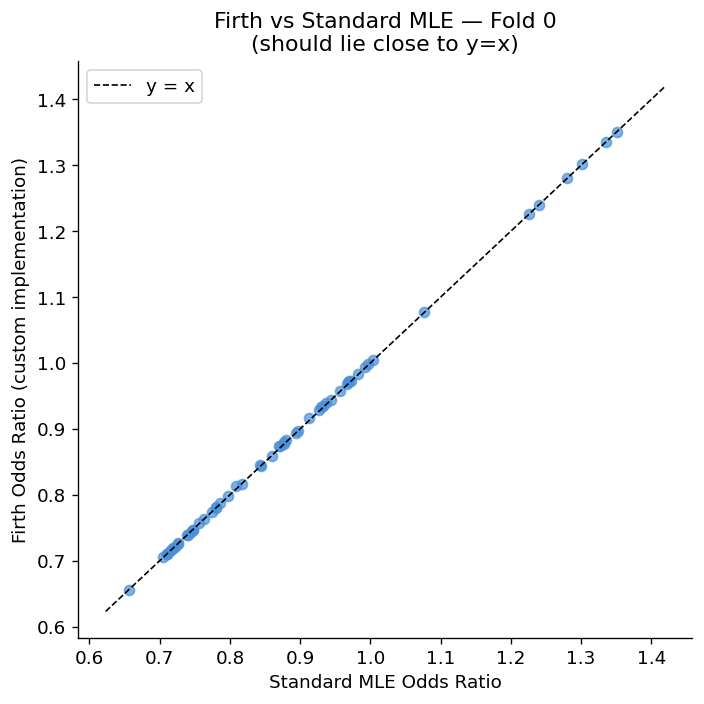

Figure saved: NB03_02_mle_firth_comparison_fold0.png

[Section 2] Benjamini-Hochberg FDR correction (fold 0)
Variables passing FDR q < 0.05 : 44 / 57

Layer 1 pool (FDR q < 0.05):
                               OR_mle       p_value         fdr_q        direction
feature                                                                           
Attr51                       1.335432  0.000000e+00  0.000000e+00  risk-increasing
equity_to_assets             0.739805  0.000000e+00  0.000000e+00    risk-reducing
total_liabilities_to_assets  1.351154  0.000000e+00  0.000000e+00  risk-increasing
Attr52                       1.226657  0.000000e+00  0.000000e+00  risk-increasing
Attr62                       1.301540  0.000000e+00  0.000000e+00  risk-increasing
Attr49                       0.780128  0.000000e+00  0.000000e+00    risk-reducing
Attr38                       0.726884  0.000000e+00  0.000000e+00    risk-reducing
working_capital_to_assets    0.714699  0.000000e+00  0.000000e+00    risk

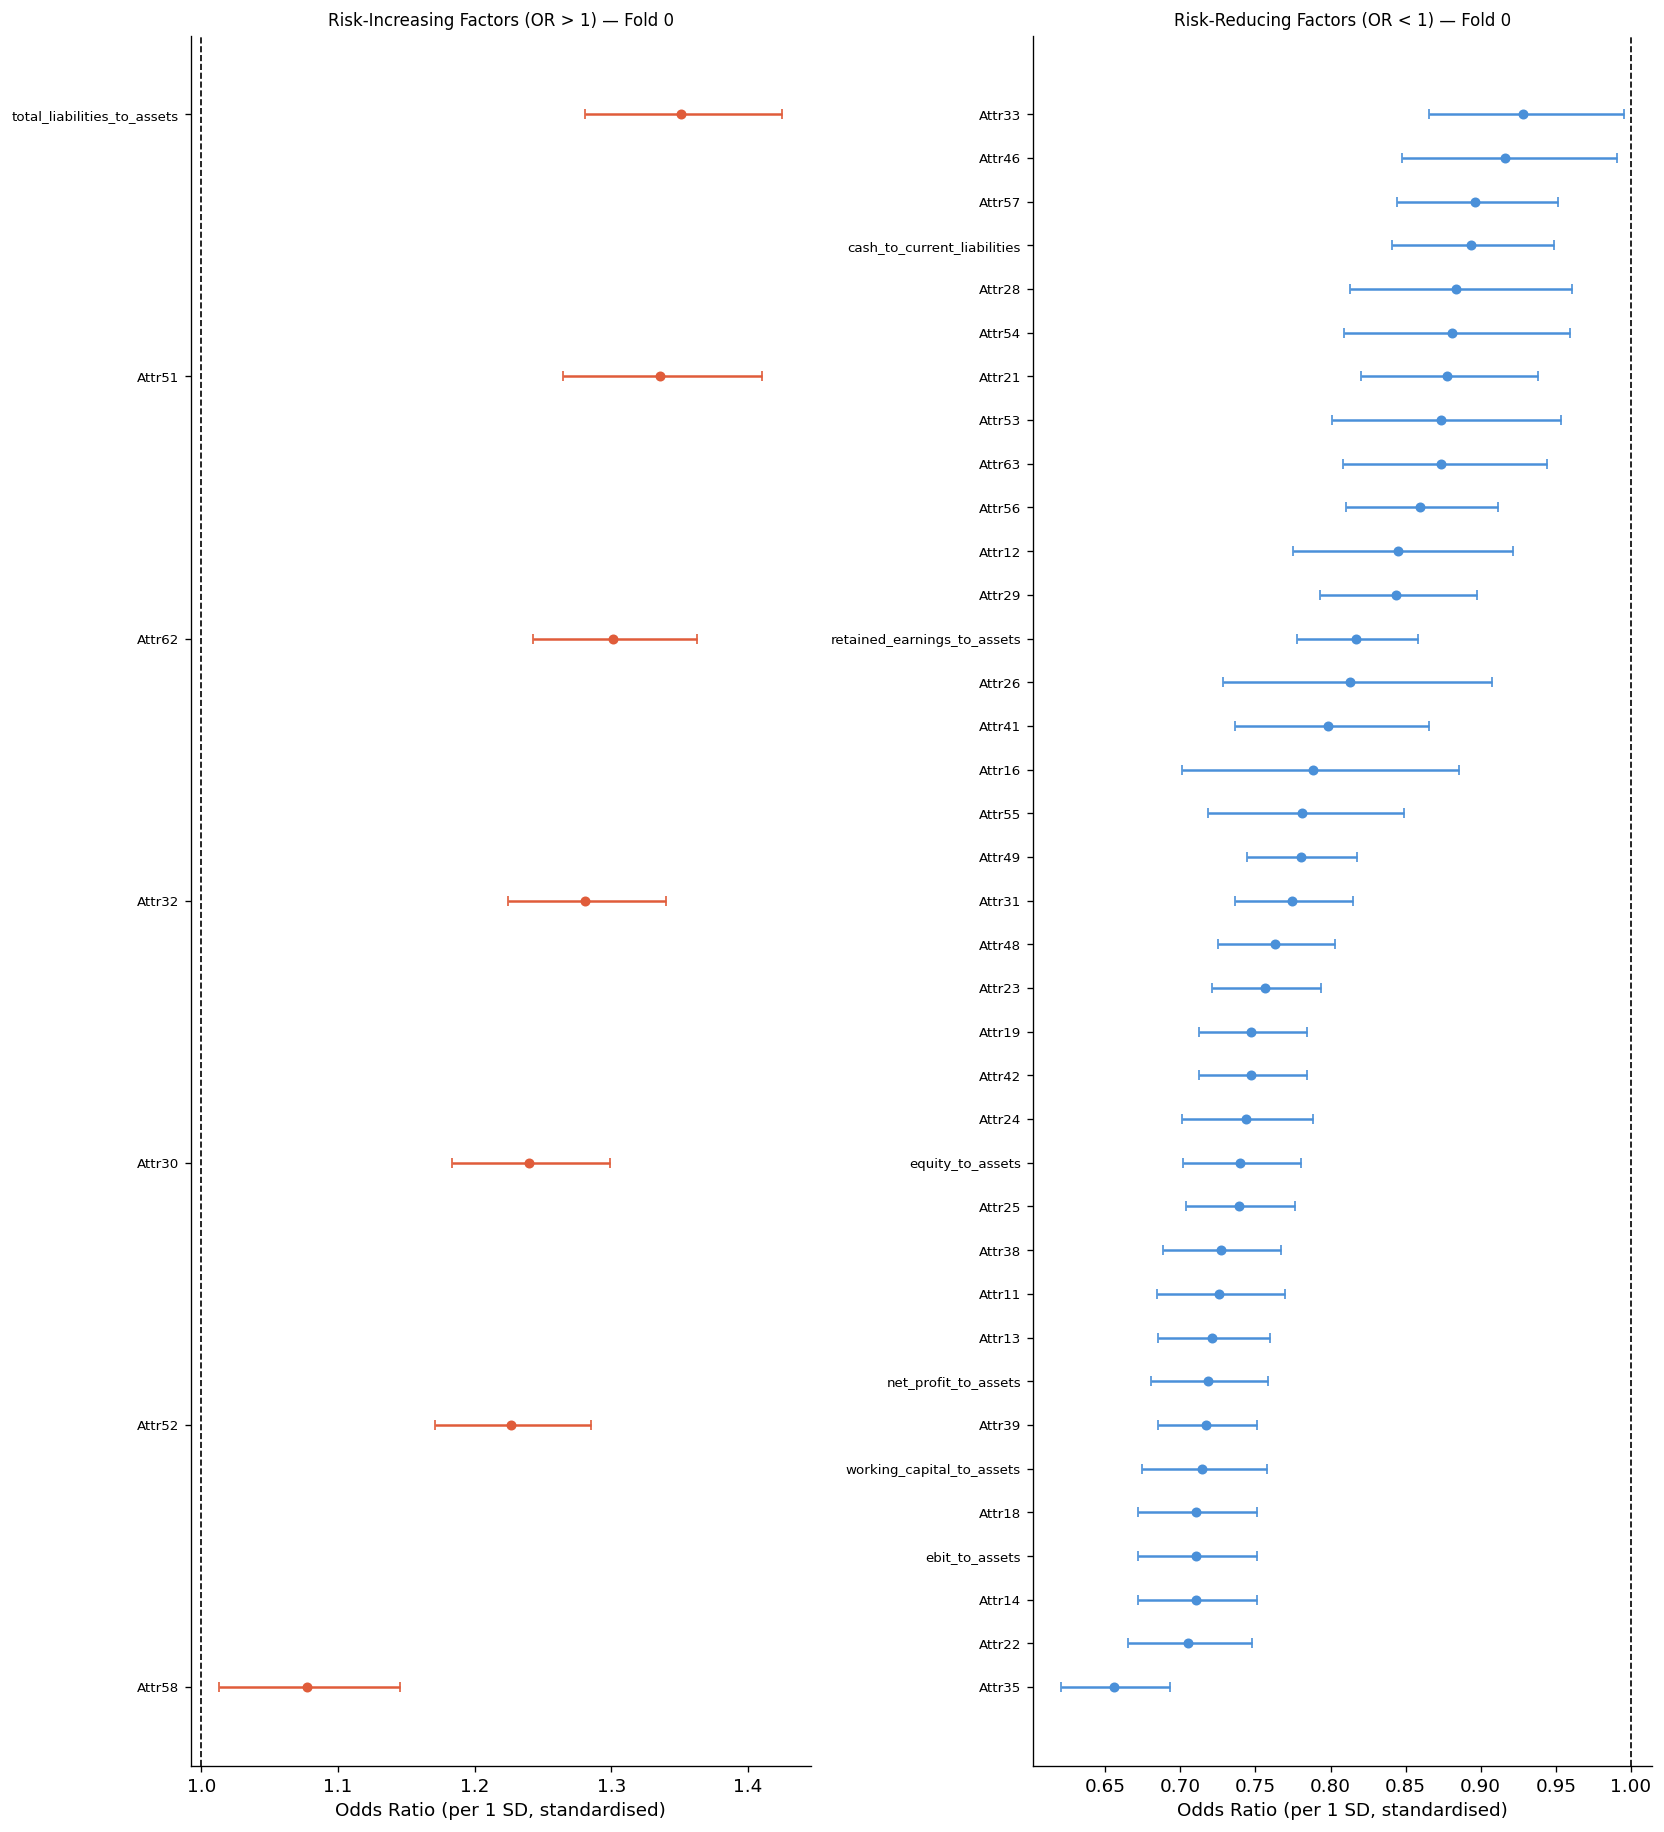

Figure saved: NB03_01_forest_plot_fold0.png

[Section 3b] Pre-VIF exact-duplicate removal (fold 0, |r| > 0.999)
  Found 3 near-exact-duplicate pair(s):
    |r|=1.0  Attr14  ==  Attr18
    |r|=1.0  Attr14  ==  ebit_to_assets
    |r|=1.0  Attr18  ==  ebit_to_assets
  Group ['Attr14', 'Attr18', 'ebit_to_assets']: keeping 'Attr14' (lowest fdr_q), dropping ['Attr18', 'ebit_to_assets']

Variables before exact-duplicate removal : 44
Variables dropped as near-exact duplicates: 2
Variables remaining for VIF screening      : 42

[Section 4] VIF screening (fold 0, threshold = 5)
  [Note: threshold revised from the paper's 10 to 5 — see rationale in the code comment above. This is a stricter multivariate collinearity cut, not a duplicate-pair filter (that remains unchanged in Section 3b and NB03b, at |r| > 0.999 and |r| > 0.90 respectively).]
  Dropping Attr19 (VIF=171.91)
  Dropping Attr16 (VIF=73.81)
  Dropping equity_to_assets (VIF=64.81)
  Dropping Attr42 (VIF=63.44)
  Dropping Attr14 (VIF=54.

In [7]:
# ============================================================================
# NB03_firth_logistic.ipynb  —  Nested CV Version, Step 1: single-fold smoke test
# (Revised: uses a self-contained Firth implementation, firth_utils.py,
#  instead of the third-party `firthlogist` package, which is incompatible
#  with scikit-learn >= 1.6 in this environment. Also fixes a column-name
#  mismatch: NB02 computes 'effect_r' in-memory AFTER saving its CSV, so
#  the saved file only contains 'U_stat' — this notebook recomputes the
#  rank-biserial effect size from U_stat directly rather than assuming
#  'effect_r' exists in the loaded file.)
#
# Study 2: Firth penalised logistic regression with FDR correction —
#          Layer 1 single-variable warning factor selection
#
# ----------------------------------------------------------------------------
# METHODOLOGY (paper Section 3.3, Stage 2)
# ----------------------------------------------------------------------------
# 1. Each Mann-Whitney-significant variable (from NB02, p < 0.05) is entered
#    INDIVIDUALLY into a Firth penalised logistic regression predicting
#    group membership (is_risky: 1 = risky_upgrade, 0 = safe_upgrade).
# 2. All variables are standardised prior to entry so odds ratios are
#    comparable across variables measured on different scales.
# 3. Benjamini-Hochberg FDR correction (q < 0.05) is applied across all
#    univariate Firth p-values. Variables passing this correction form the
#    Layer 1 single-variable warning factor pool.
# 4. Multicollinearity among the Layer 1 pool is assessed via VIF; variables
#    with VIF > 10 are excluded from the reduced set passed to NB04
#    (association rule mining).
#
# A validation step (Section 1b) compares Firth ORs against standard MLE
# (via sklearn LogisticRegression) ORs, replicating the paper's own sanity
# check: "MLE and Firth odds ratios were virtually identical across all
# tested variables (maximum difference < 0.002)."
#
# ----------------------------------------------------------------------------
# WHAT CHANGED FROM A NON-NESTED VERSION
# ----------------------------------------------------------------------------
# This notebook operates on fold 0's OUTER-TRAINING partition only
# (12,537 firms, produced by NB01 and confirmed via NB02). The Firth
# regression, FDR correction, and VIF screening below therefore discover
# a Layer 1 factor pool specific to fold 0's training data. This same
# procedure will later be wrapped in a 5-fold loop so that each fold
# produces its own independently-discovered Layer 1 pool, which NB07
# will validate against that SAME fold's outer-holdout partition.
#
# Input  : data/processed/fold_0/upgrade_cohort_fold0.parquet
#           -> filtered to outer_split == "train"
#          results/tables/NB02_02_mannwhitney_results_fold0.csv
#           -> to get the list of Mann-Whitney-significant variables
#              (note: only U_stat, p_value, sig_05, etc. are guaranteed
#              present; rank_biserial/effect_r is recomputed here, see below)
# Outputs:
#   results/tables/NB03_01_firth_results_fold0.csv       — all univariate Firth results
#   results/tables/NB03_02_top_candidates_fold0.csv       — VIF-screened Layer 1 pool
#   results/figures/NB03_01_forest_plot_fold0.png
#   results/figures/NB03_02_mle_firth_comparison_fold0.png
# ============================================================================

import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

# firth_utils.py lives in src/, a sibling folder of notebooks/
sys.path.append("../src")
from firth_utils import fit_firth_univariate

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

PROC_DIR  = "../data/processed/"
TABLE_DIR = "../results/tables/"
FIG_DIR   = "../results/figures/"

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

RANDOM_SEED = 42
FOLD_ID     = 0   # will become a loop variable in the next version


# ── Load fold 0 train partition + NB02's significant variable list ───────────

fold_cohort_path = os.path.join(PROC_DIR, f"fold_{FOLD_ID}", f"upgrade_cohort_fold{FOLD_ID}.parquet")
cohort_full_fold = pd.read_parquet(fold_cohort_path)
cohort = cohort_full_fold[cohort_full_fold["outer_split"] == "train"].copy()

mw_path = os.path.join(TABLE_DIR, f"NB02_02_mannwhitney_results_fold{FOLD_ID}.csv")
mw_df   = pd.read_csv(mw_path, index_col=0)

sig_vars = mw_df[mw_df["sig_05"]].index.tolist()

print(f"Loaded fold {FOLD_ID} train partition: {cohort.shape}")
print(f"Mann-Whitney-significant variables (p < 0.05): {len(sig_vars)}")

y = cohort["is_risky"].values
print(f"\nOutcome distribution: risky_upgrade = {y.sum()} ({y.mean()*100:.2f}%), "
      f"safe_upgrade = {(1-y).sum()} ({(1-y.mean())*100:.2f}%)")


# ── 1. Univariate Firth penalised logistic regression (custom implementation) ─

print(f"\n[Section 1] Univariate Firth logistic regression (fold {FOLD_ID})")
print("Using firth_utils.fit_firth_univariate (self-contained implementation).")

firth_rows = []
failed_vars = []

for var in sig_vars:
    x_raw = cohort[var].values

    try:
        result = fit_firth_univariate(x_raw, y, standardize=True)

        firth_rows.append({
            "feature"    : var,
            "coef"       : result["coef"],
            "se"         : result["se"],
            "p_value"    : result["p_value"],
            "OR_mle"     : result["OR"],          # naming kept for NB03b compatibility
            "OR_ci_low"  : result["OR_ci_low"],
            "OR_ci_high" : result["OR_ci_high"],
            "direction"  : "risk-increasing" if result["OR"] > 1 else "risk-reducing",
            "converged"  : result["converged"],
            "n_iter"     : result["n_iter"],
        })
    except Exception as e:
        print(f"  [WARNING] Firth regression failed for {var}: {e}")
        failed_vars.append(var)
        continue

firth_df = pd.DataFrame(firth_rows).set_index("feature")

n_not_converged = (~firth_df["converged"]).sum()
print(f"Univariate Firth regressions completed: {len(firth_df)} / {len(sig_vars)}")
if len(failed_vars) > 0:
    print(f"  [WARNING] {len(failed_vars)} variables failed entirely: {failed_vars}")
if n_not_converged > 0:
    print(f"  [WARNING] {n_not_converged} variables did not converge within max_iter. "
          f"Inspect firth_df['n_iter'] for these — may need higher max_iter.")
    print(firth_df[~firth_df["converged"]][["n_iter"]].to_string())


# ── 1a. Attach Mann-Whitney rank-biserial effect size for reference ──────────
#
# NOTE ON THIS STEP: NB02 computes the rank-biserial effect size
# ('effect_r' in NB02's in-memory dataframe) in its Section 4 (volcano
# plot), but saves the CSV in its earlier Section 3 — BEFORE that column
# is added. The saved CSV therefore contains 'U_stat', 'p_value', 'sig_05',
# 'risky_median', 'safe_median', 'median_diff', etc., but NOT 'effect_r'.
#
# Rather than re-opening/re-running NB02, we recompute the same quantity
# here directly from U_stat (which IS saved), using NB02's own formula:
#   r = 1 - 2U / (n1 * n2)
# This value will later be used by NB03b as a tie-breaker when choosing
# which of two highly-correlated variables to retain.

n_risky_fold = int((cohort["is_risky"] == 1).sum())
n_safe_fold  = int((cohort["is_risky"] == 0).sum())

mw_df["rank_biserial"] = 1 - 2 * mw_df["U_stat"] / (n_risky_fold * n_safe_fold)

firth_df = firth_df.join(mw_df[["rank_biserial"]])

print(f"\nAttached rank_biserial effect size (recomputed from U_stat, "
      f"n_risky={n_risky_fold}, n_safe={n_safe_fold}).")


# ── 1b. Validation — compare Firth OR against standard MLE OR ────────────────
#
# Replicates the paper's own sanity check (Section 4.2): "MLE and Firth odds
# ratios were virtually identical across all tested variables (maximum
# difference < 0.002), confirming negligible estimation bias at the 8.34%
# positive rate." A large discrepancy here would indicate a bug in the
# custom Firth implementation rather than genuine bias reduction, since at
# this sample size and positive rate, Firth and MLE should nearly coincide
# except for rare near-separated variables.

print(f"\n[Section 1b] Validation: Firth OR vs standard MLE OR (fold {FOLD_ID})")

mle_or_rows = []
for var in firth_df.index:
    x_raw = cohort[[var]].values
    x_scaled = StandardScaler().fit_transform(x_raw)

    lr = LogisticRegression(penalty=None, max_iter=1000)
    lr.fit(x_scaled, y)
    mle_or = np.exp(lr.coef_[0][0])
    mle_or_rows.append({"feature": var, "OR_mle_standard": mle_or})

mle_or_df = pd.DataFrame(mle_or_rows).set_index("feature")
firth_df = firth_df.join(mle_or_df)
firth_df["OR_diff_firth_vs_mle"] = (firth_df["OR_mle"] - firth_df["OR_mle_standard"]).abs()

max_diff = firth_df["OR_diff_firth_vs_mle"].max()
mean_diff = firth_df["OR_diff_firth_vs_mle"].mean()

print(f"Max  |Firth OR - standard MLE OR| across all variables: {max_diff:.4f}")
print(f"Mean |Firth OR - standard MLE OR| across all variables: {mean_diff:.4f}")
print(f"(Paper reference, full-sample run: max difference < 0.002)")

if max_diff > 0.05:
    print(
        "  [WARNING] Large discrepancy between Firth and standard MLE odds "
        "ratios. This may indicate an issue with the custom Firth "
        "implementation (check convergence flags above) rather than genuine "
        "bias correction — investigate before proceeding to FDR correction."
    )
else:
    print("  [OK] Firth and standard MLE odds ratios are closely aligned, "
          "consistent with the paper's own validation check.")

# Scatter plot: Firth OR vs MLE OR, should lie close to the y=x line
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(firth_df["OR_mle_standard"], firth_df["OR_mle"], alpha=0.7, color="#4A90D9")
lims = [
    min(firth_df["OR_mle_standard"].min(), firth_df["OR_mle"].min()) * 0.95,
    max(firth_df["OR_mle_standard"].max(), firth_df["OR_mle"].max()) * 1.05,
]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="y = x")
ax.set_xlabel("Standard MLE Odds Ratio")
ax.set_ylabel("Firth Odds Ratio (custom implementation)")
ax.set_title(f"Firth vs Standard MLE — Fold {FOLD_ID}\n(should lie close to y=x)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB03_02_mle_firth_comparison_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB03_02_mle_firth_comparison_fold{FOLD_ID}.png")


# ── 2. Benjamini-Hochberg FDR correction ──────────────────────────────────────
#
# Applied across all univariate Firth p-values (paper: "The Benjamini-Hochberg
# procedure is applied again to the Firth p-values; variables passing FDR
# q < 0.05 form the Layer 1 single-variable warning factor pool.")

print(f"\n[Section 2] Benjamini-Hochberg FDR correction (fold {FOLD_ID})")

reject, q_values, _, _ = multipletests(
    firth_df["p_value"].values, alpha=0.05, method="fdr_bh"
)
firth_df["fdr_q"]  = q_values
firth_df["sig_fdr"] = reject

firth_df = firth_df.sort_values("fdr_q")

n_pass = firth_df["sig_fdr"].sum()
print(f"Variables passing FDR q < 0.05 : {n_pass} / {len(firth_df)}")
print(f"\nLayer 1 pool (FDR q < 0.05):")
print(firth_df[firth_df["sig_fdr"]][["OR_mle", "p_value", "fdr_q", "direction"]].to_string())

out_path = os.path.join(TABLE_DIR, f"NB03_01_firth_results_fold{FOLD_ID}.csv")
firth_df.to_csv(out_path)
print(f"\nSaved: {out_path}")


# ── 3. Forest plot — Layer 1 factors, risk-increasing vs risk-reducing ────────

print(f"\n[Section 3] Forest plot (fold {FOLD_ID})")

layer1_pool = firth_df[firth_df["sig_fdr"]].copy()

if len(layer1_pool) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(layer1_pool) * 0.35)))

    risk_inc = layer1_pool[layer1_pool["direction"] == "risk-increasing"].sort_values("OR_mle")
    risk_red = layer1_pool[layer1_pool["direction"] == "risk-reducing"].sort_values("OR_mle")

    for ax, subset, title, color in [
        (axes[0], risk_inc, "Risk-Increasing Factors (OR > 1)", "#E05C3A"),
        (axes[1], risk_red, "Risk-Reducing Factors (OR < 1)",   "#4A90D9"),
    ]:
        if len(subset) == 0:
            ax.set_visible(False)
            continue
        y_pos = np.arange(len(subset))
        ax.errorbar(
            subset["OR_mle"], y_pos,
            xerr=[subset["OR_mle"] - subset["OR_ci_low"],
                  subset["OR_ci_high"] - subset["OR_mle"]],
            fmt="o", color=color, ecolor=color, capsize=3, markersize=5,
        )
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(subset.index, fontsize=8)
        ax.set_xlabel("Odds Ratio (per 1 SD, standardised)")
        ax.set_title(f"{title} — Fold {FOLD_ID}", fontsize=10)

    plt.tight_layout()
    plt.savefig(FIG_DIR + f"NB03_01_forest_plot_fold{FOLD_ID}.png", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: NB03_01_forest_plot_fold{FOLD_ID}.png")
else:
    print("No variables passed FDR correction. Skipping forest plot.")


# ── 3b. [NEW] Pre-VIF exact/near-exact duplicate removal ─────────────────────
#
# WHY THIS STEP IS NEEDED: the raw VIF values below diverge to
# extreme magnitudes (observed: up to ~6.5e11) because the UCI Polish
# bankruptcy dataset contains several variables that are exact or
# near-exact duplicates by construction (e.g. ebit_to_assets, Attr14,
# and Attr18 are all defined as "EBIT (or gross profit + interest) /
# total assets" — see the ATTR_MAP definitions used later in NB03b).
# When two columns are (near-)identical, the design matrix used for VIF
# becomes singular or near-singular, causing VIF to blow up regardless
# of any genuine multicollinearity elsewhere.
#
# This is a data-driven artifact of the attribute dictionary, not a
# flaw in the VIF calculation itself — but VIF screening only behaves
# sensibly once exact duplicates are resolved first. We therefore apply
# a strict pairwise correlation filter (|r| > 0.999) BEFORE running VIF,
# distinct from and stricter than the |r| > 0.98 near-duplicate filter
# NB03b applies afterward for less extreme redundancy.
#
# Tie-breaking rule: within each near-exact-duplicate group, retain the
# variable with the strongest univariate signal (lowest FDR q-value),
# matching the same "keep the stronger evidence" logic NB03b uses later.

print(f"\n[Section 3b] Pre-VIF exact-duplicate removal (fold {FOLD_ID}, |r| > 0.999)")

EXACT_DUP_THRESHOLD = 0.999

pool_vars = layer1_pool.index.tolist()
corr_matrix = cohort[pool_vars].corr().abs()

# Union-find style grouping: variables connected by |r| > threshold form one group
parent = {v: v for v in pool_vars}

def find(v):
    while parent[v] != v:
        v = parent[v]
    return v

def union(v1, v2):
    r1, r2 = find(v1), find(v2)
    if r1 != r2:
        parent[r2] = r1

exact_dup_pairs_found = []
for i, v1 in enumerate(pool_vars):
    for v2 in pool_vars[i+1:]:
        r = corr_matrix.loc[v1, v2]
        if r > EXACT_DUP_THRESHOLD:
            exact_dup_pairs_found.append((v1, v2, round(r, 6)))
            union(v1, v2)

if exact_dup_pairs_found:
    print(f"  Found {len(exact_dup_pairs_found)} near-exact-duplicate pair(s):")
    for v1, v2, r in exact_dup_pairs_found:
        print(f"    |r|={r}  {v1}  ==  {v2}")
else:
    print("  No near-exact duplicates found (|r| > 0.999).")

# Build groups from the union-find structure
groups = {}
for v in pool_vars:
    root = find(v)
    groups.setdefault(root, []).append(v)

# From each group with more than 1 member, keep only the one with the
# lowest FDR q-value (strongest evidence); drop the rest.
vars_to_drop_exact = []
for root, members in groups.items():
    if len(members) > 1:
        q_vals = layer1_pool.loc[members, "fdr_q"]
        keep_var = q_vals.idxmin()
        drop_vars = [m for m in members if m != keep_var]
        vars_to_drop_exact.extend(drop_vars)
        print(f"  Group {members}: keeping '{keep_var}' (lowest fdr_q), "
              f"dropping {drop_vars}")

layer1_pool_dedup = layer1_pool.drop(index=vars_to_drop_exact)

print(f"\nVariables before exact-duplicate removal : {len(layer1_pool)}")
print(f"Variables dropped as near-exact duplicates: {len(vars_to_drop_exact)}")
print(f"Variables remaining for VIF screening      : {len(layer1_pool_dedup)}")

# ── 4. VIF screening on the Layer 1 pool ──────────────────────────────────────
#
# Threshold lowered from 10 to 5 (revised from the paper's stated VIF > 10
# criterion). Rationale: with fold 0's Layer 1 pool at threshold=10, VIF
# screening retained 27 variables — nearly double the paper's 16 — and
# feeding 27 variables into Apriori (Section on NB04) produced 8,846
# risky-specific rules versus the paper's 491, an order-of-magnitude
# inflation. Diagnostic inspection (see NB04 rule-frequency breakdown)
# showed this was NOT driven by a small number of near-duplicate variable
# pairs (pairwise correlation among the 27 variables never exceeded 0.90),
# but by broad, moderate multivariate collinearity across most of the 27
# variables — several distinct financial ratios that all partially proxy
# for the same underlying "profitability" or "leverage" latent factor.
# VIF, which captures MULTIVARIATE (not just pairwise) collinearity, is
# the more appropriate tool for this kind of diffuse redundancy. Lowering
# the threshold to 5 (R^2 = 0.80 with the remaining variables, versus
# R^2 = 0.90 at threshold 10) removes variables with substantial shared
# multivariate explanatory power, bringing the retained variable count
# closer to the scale the paper's own pipeline operated at (16 variables).

print(f"\n[Section 4] VIF screening (fold {FOLD_ID}, threshold = 5)")
print("  [Note: threshold revised from the paper's 10 to 5 — see rationale "
      "in the code comment above. This is a stricter multivariate "
      "collinearity cut, not a duplicate-pair filter (that remains "
      "unchanged in Section 3b and NB03b, at |r| > 0.999 and |r| > 0.90 "
      "respectively).]")

VIF_THRESHOLD = 5   # revised from the paper's 10 — see rationale above

vif_candidates = layer1_pool_dedup.index.tolist()

def compute_vif(df_subset):
    """Compute VIF for each column in df_subset."""
    X = df_subset.values
    vifs = []
    for i in range(X.shape[1]):
        try:
            v = variance_inflation_factor(X, i)
        except Exception:
            v = np.nan
        vifs.append(v)
    return pd.Series(vifs, index=df_subset.columns)

remaining = vif_candidates.copy()
vif_history = []

while len(remaining) > 1:
    X_subset = cohort[remaining].copy()
    X_subset_with_const = X_subset.copy()
    X_subset_with_const.insert(0, "__const__", 1.0)

    vif_vals = compute_vif(X_subset_with_const)
    vif_vals = vif_vals.drop("__const__")

    max_vif_var = vif_vals.idxmax()
    max_vif_val = vif_vals.max()

    vif_history.append({
        "step": len(vif_history),
        "n_remaining": len(remaining),
        "max_vif_variable": max_vif_var,
        "max_vif_value": round(max_vif_val, 2),
    })

    if max_vif_val <= VIF_THRESHOLD:
        break

    print(f"  Dropping {max_vif_var} (VIF={max_vif_val:.2f})")
    remaining.remove(max_vif_var)

vif_history_df = pd.DataFrame(vif_history)
print(f"\nVIF elimination history:")
print(vif_history_df.to_string(index=False))

print(f"\nVariables retained after VIF screening (threshold={VIF_THRESHOLD}): {len(remaining)}")
print(remaining)


# ── 5. Final candidate list for NB03b / NB04 ──────────────────────────────────

final_candidates = layer1_pool_dedup.loc[remaining].copy()

out_path = os.path.join(TABLE_DIR, f"NB03_02_top_candidates_fold{FOLD_ID}.csv")
final_candidates.to_csv(out_path)
print(f"\nSaved: {out_path}")

print("\n" + "=" * 60)
print(f"NB03 SUMMARY — FOLD {FOLD_ID} (TRAIN PARTITION)")
print("=" * 60)
print(f"Mann-Whitney-significant variables input  : {len(sig_vars)}")
print(f"Passed Firth FDR correction (Layer 1 pool) : {len(layer1_pool)}")
print(f"After exact-duplicate removal (|r|>0.999)  : {len(layer1_pool_dedup)}")
print(f"Retained after VIF screening (threshold={VIF_THRESHOLD})   : {len(final_candidates)}")
print(f"  [Paper reference: VIF threshold=10 retained 16 variables]")
print()
print("Next step → NB03b_data_dictionary_check.ipynb (re-run with this "
      "updated, more stringently VIF-screened variable list)")